# 02 — Modeling: LogReg, SVM, MLP on Shooter + Keeper tasks

We train three algorithms on **two prediction tasks**:

| Task | Type | Target |
|---|---|---|
| Shooter | Binary classification | Scored / Missed |
| Keeper  | 6-class classification | Angle (corner) |

**Protocol**
- 80/20 stratified random split, `random_state=42`.
- 3-fold GridSearchCV on the training set.
- Shooter: `class_weight='balanced'` (LogReg/SVM), SMOTE (MLP).
- Keeper: SMOTE on training fold for all three.
- All artifacts (joblibs, PNGs, results.csv) saved under `models/` and `report/figures/`.

The actual training is implemented as the reusable module `src/train.py`; this notebook calls it and inspects the results.

In [1]:
import sys
from pathlib import Path
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.train import main as train_main

## 1. Train everything

This runs the full pipeline (~30s on CPU). Re-run any time you change features.

Loaded 628 rows.

=== Shooter task (binary: Scored / Missed) ===


 model  accuracy  roc_auc       f1                           best_params
LogReg  0.571429 0.548755 0.686047                      {"clf__C": 10.0}
   SVM  0.611111 0.581258 0.720000 {"clf__C": 0.5, "clf__kernel": "rbf"}
   MLP  0.690476 0.561840 0.797927                {"clf__alpha": 0.0001}

=== Keeper task (6-class angle) ===


 model  accuracy  macro_f1  top2_accuracy                              best_params
LogReg  0.222222  0.199482       0.380952                          {"clf__C": 1.0}
   SVM  0.198413  0.166552       0.396825 {"clf__C": 5.0, "clf__kernel": "linear"}
   MLP  0.214286  0.177815       0.460317                   {"clf__alpha": 0.0001}

All artifacts saved to D:\CUFE\Eightth term\Machine Learning\Project\epl-penalty-ml\models and D:\CUFE\Eightth term\Machine Learning\Project\epl-penalty-ml\report\figures.


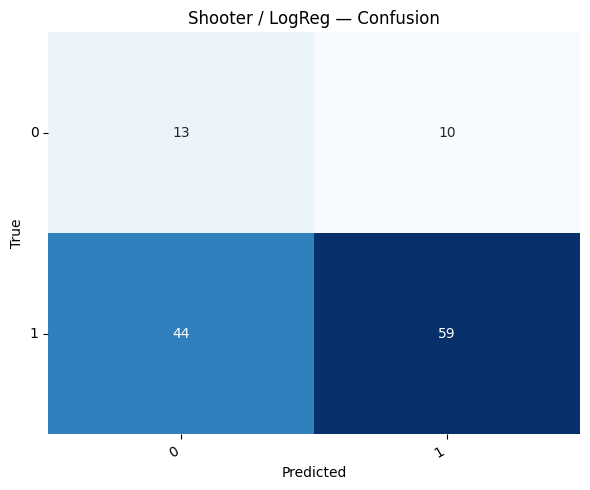

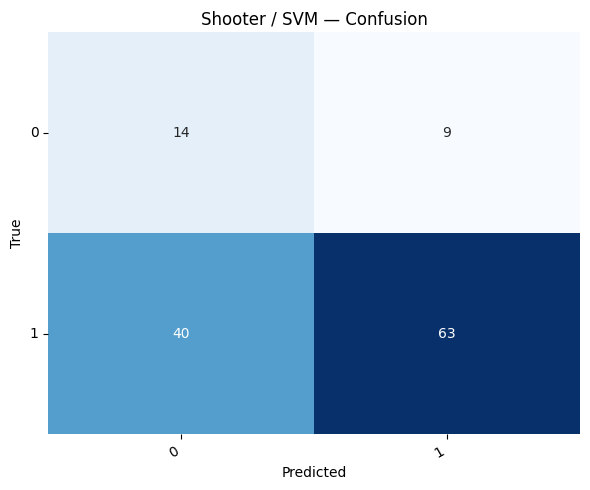

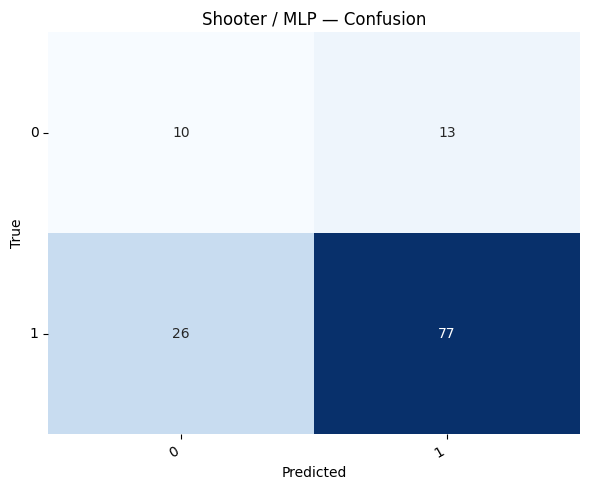

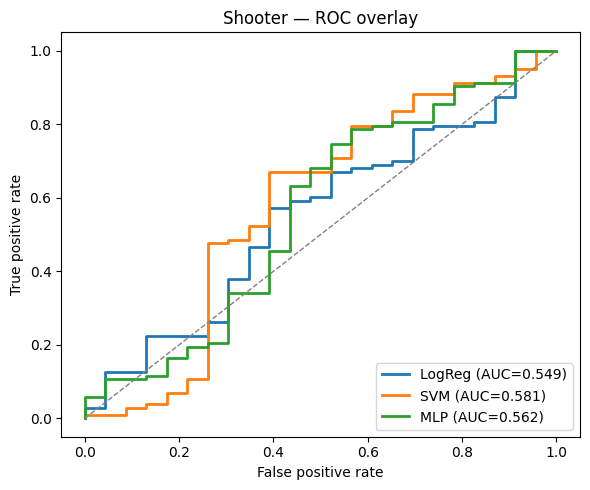

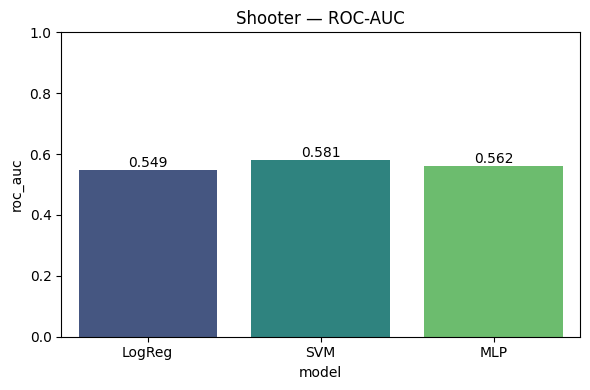

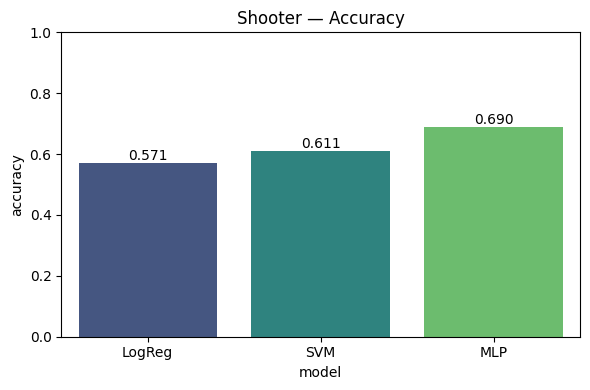

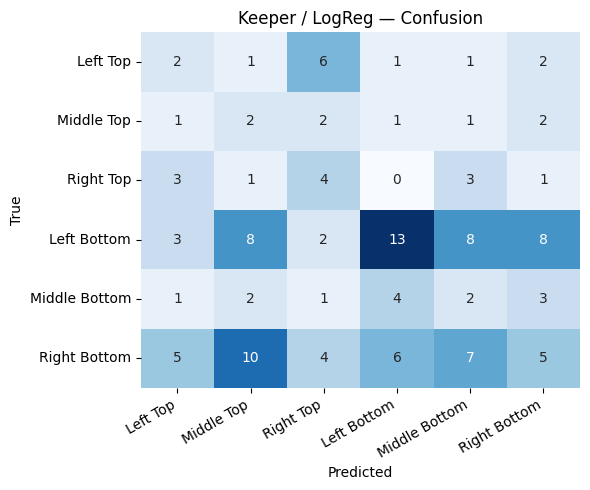

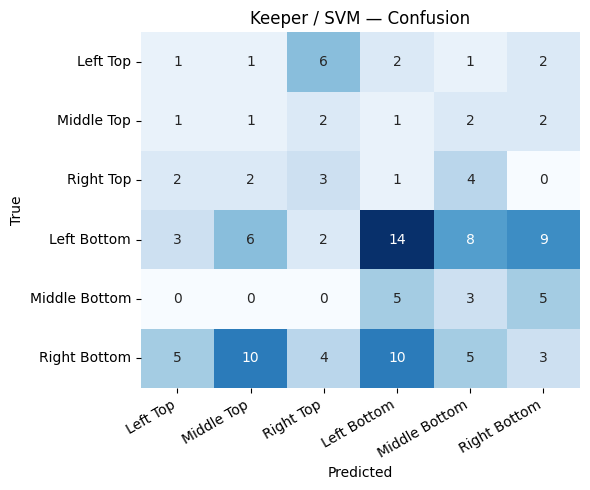

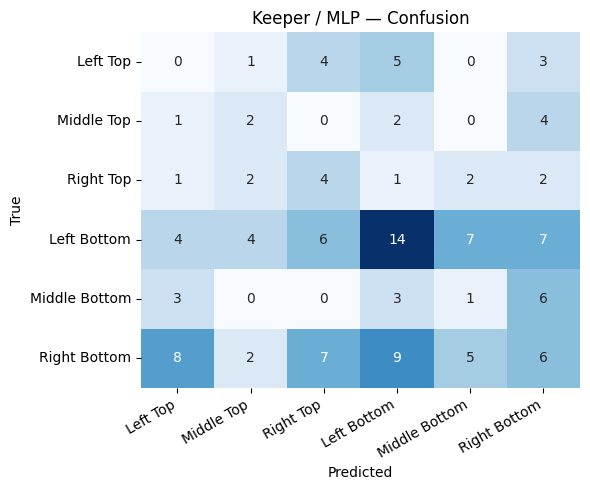

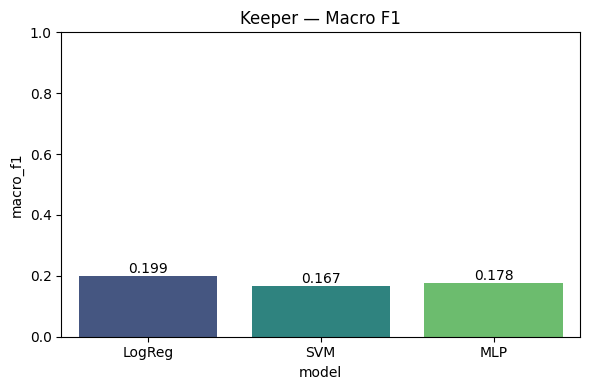

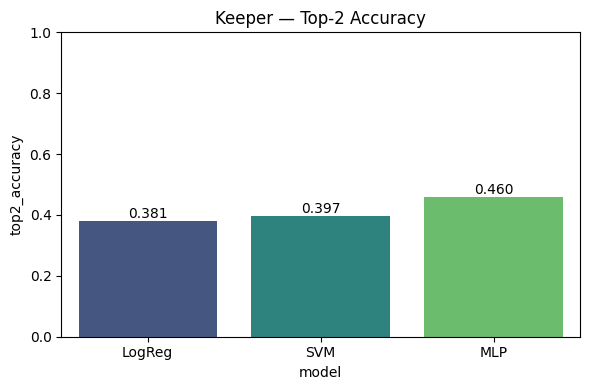

In [2]:
train_main()

## 2. Shooter results

In [3]:
shooter_res = pd.read_csv(ROOT / 'models/shooter_results.csv')
shooter_res

,model,accuracy,roc_auc,f1,best_params
0,LogReg,0.571429,0.548755,0.686047,"{""clf__C"": 10.0}"
1,SVM,0.611111,0.581258,0.720000,"{""clf__C"": 0.5, ""clf__kernel"": ""rbf""}"
2,MLP,0.690476,0.561840,0.797927,"{""clf__alpha"": 0.0001}"


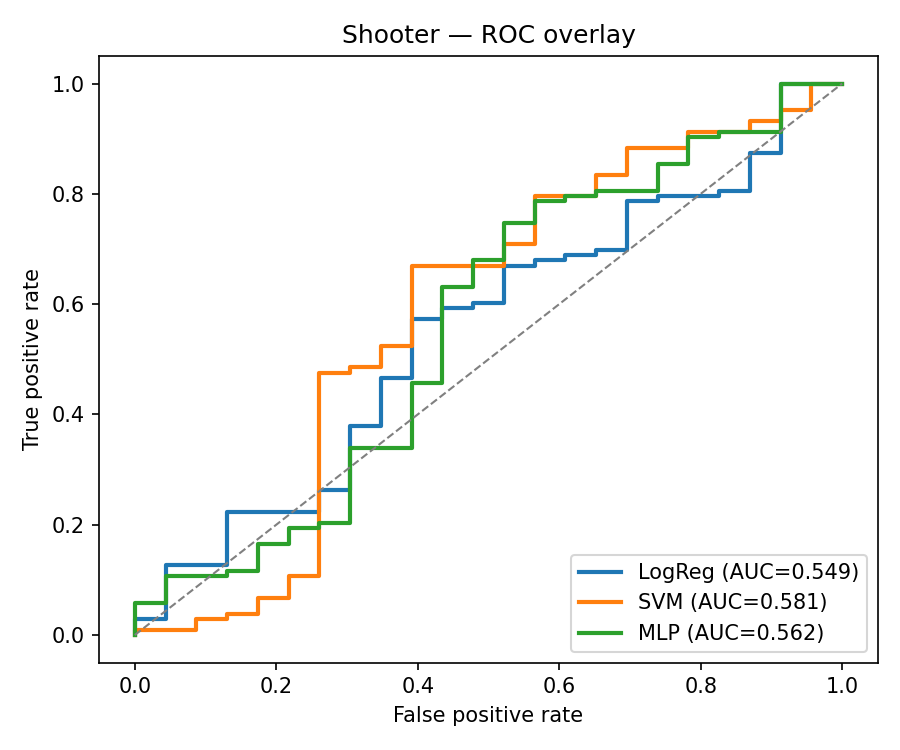

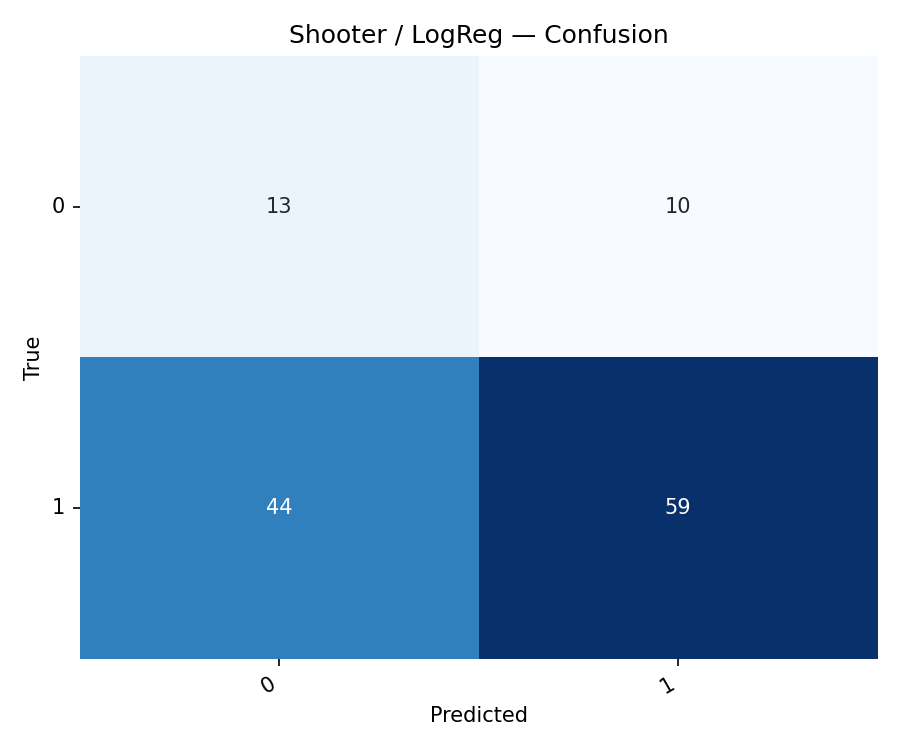

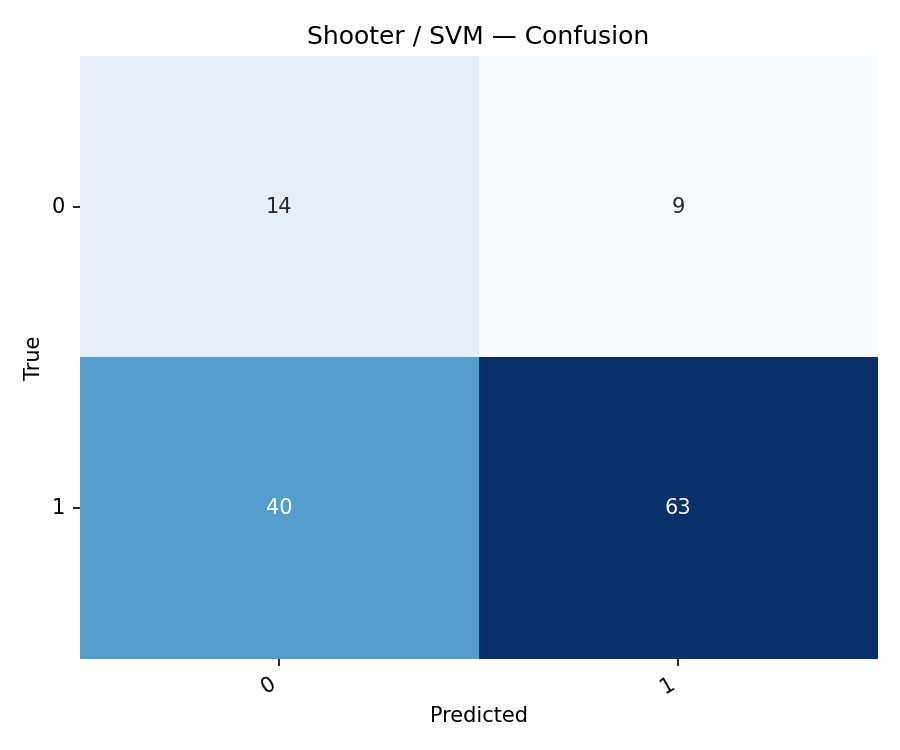

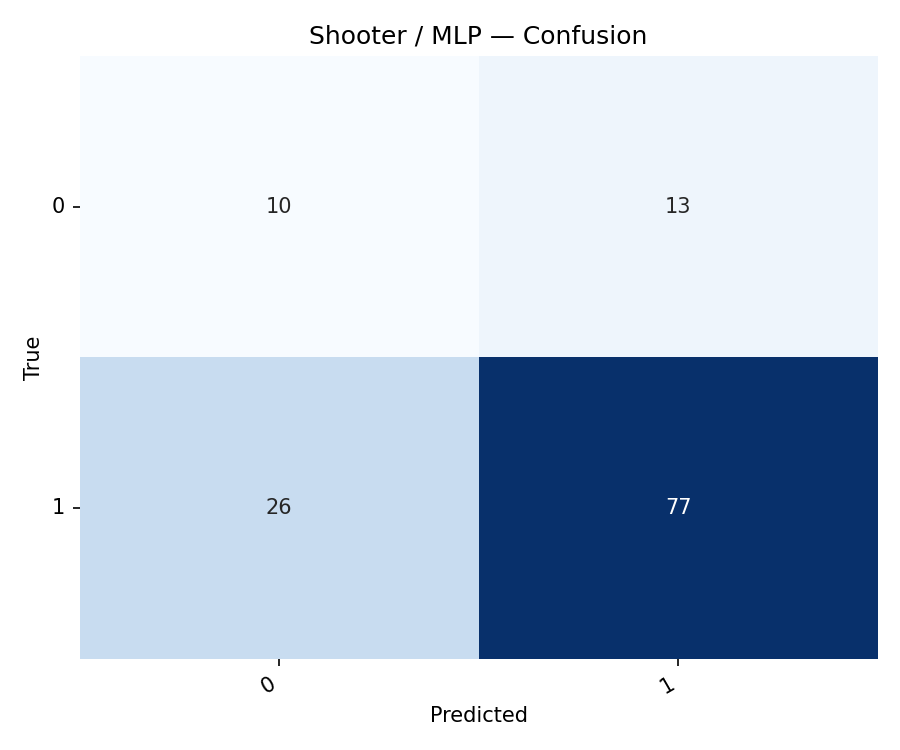

In [4]:
display(Image(ROOT / 'report/figures/shooter_roc_overlay.png'))
for name in ('logreg', 'svm', 'mlp'):
    display(Image(ROOT / f'report/figures/shooter_{name}_cm.png'))

**Shooter interpretation:** ROC-AUC is the right metric here because the baseline 'always predict Scored' achieves ~82% accuracy but no useful discrimination. AUC ~0.55-0.58 means the models are slightly informed; this is realistic for ~628 noisy penalties without rich context.

## 3. Keeper results

In [5]:
keeper_res = pd.read_csv(ROOT / 'models/keeper_results.csv')
keeper_res

,model,accuracy,macro_f1,top2_accuracy,best_params
0,LogReg,0.222222,0.199482,0.380952,"{""clf__C"": 1.0}"
1,SVM,0.198413,0.166552,0.396825,"{""clf__C"": 5.0, ""clf__kernel"": ""linear""}"
2,MLP,0.214286,0.177815,0.460317,"{""clf__alpha"": 0.0001}"


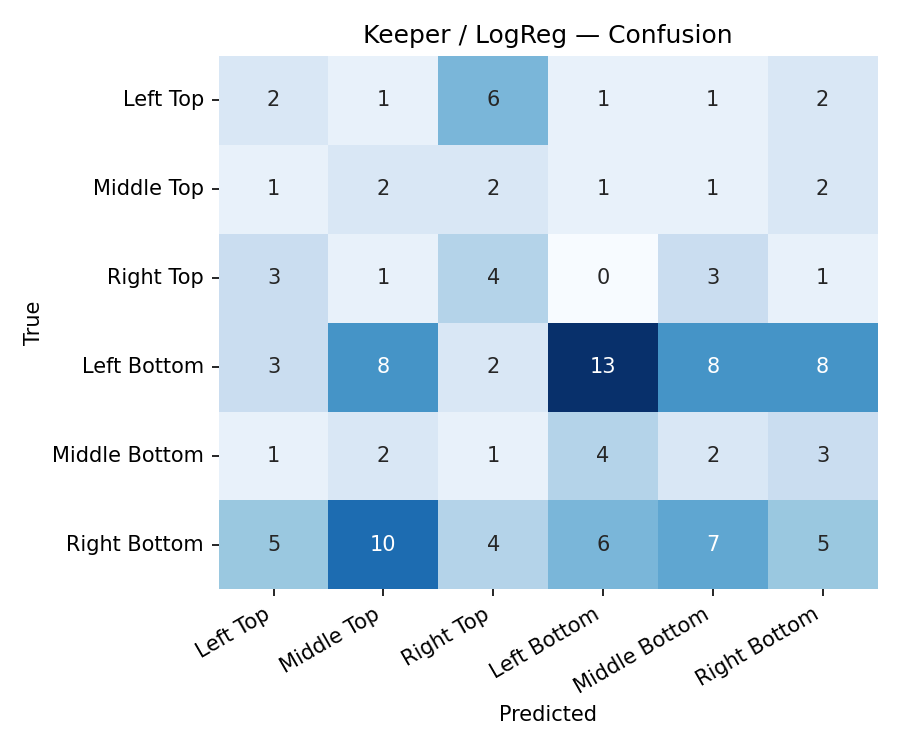

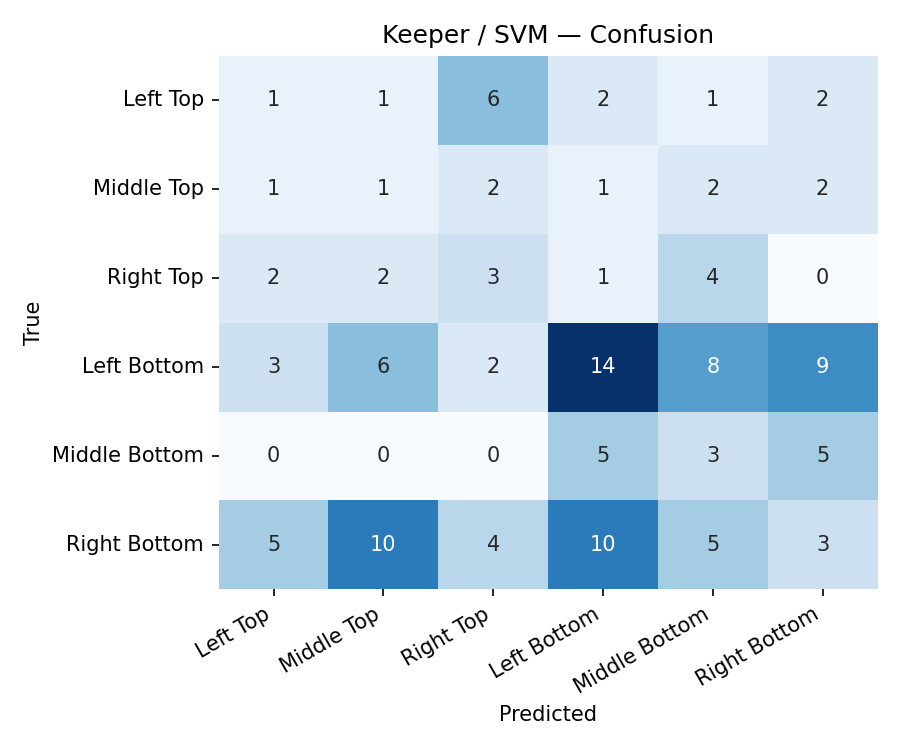

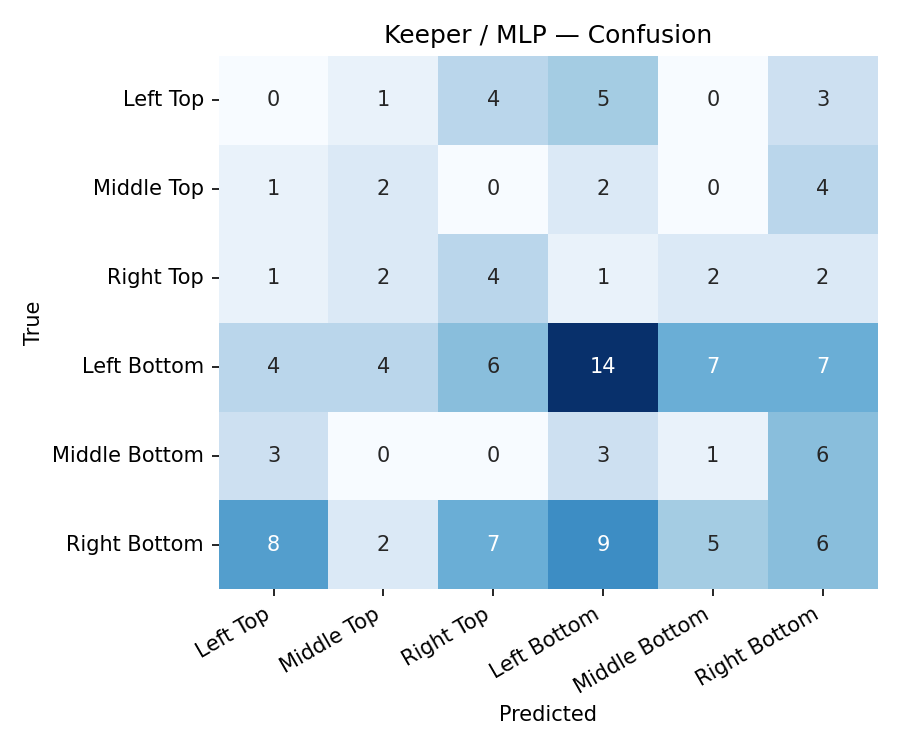

In [6]:
for name in ('logreg', 'svm', 'mlp'):
    display(Image(ROOT / f'report/figures/keeper_{name}_cm.png'))

**Keeper interpretation:** Random over 6 classes is 17% accuracy / 33% top-2. Our models reach ~20-22% accuracy and ~40-46% top-2 — a meaningful lift, though peak accuracy is modest because individual penalty placement is highly stochastic.

## 4. Comparison summary

Winning model per task (on test set):

- **Shooter:** SVM has the best ROC-AUC; MLP has the best accuracy but at the cost of AUC discrimination.
- **Keeper:** MLP wins on Top-2 accuracy, which is what powers the heatmap visualization in the Streamlit demo.
- **LogReg** is competitive on both tasks despite being the simplest model — a clear sign the signal is mostly linear at this dataset size.
